## **23CSE301 - Machine Learning - Activity 5 - K Nearest Neighbours**
### **CH.SC.U4CSE24142 - SANTHOSH**
### Date : 27/08/2026

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.neighbors import KNeighborsClassifier

In [3]:
# Load the dataset
df = pd.read_csv('9_K_Nearest_Neighbour_Dataset_Exercise_2.csv')
df.head()

,Brightness,Saturation,Class
0,40,20,Red
1,50,50,Blue
2,60,90,Blue
3,10,25,Red
4,70,70,Blue


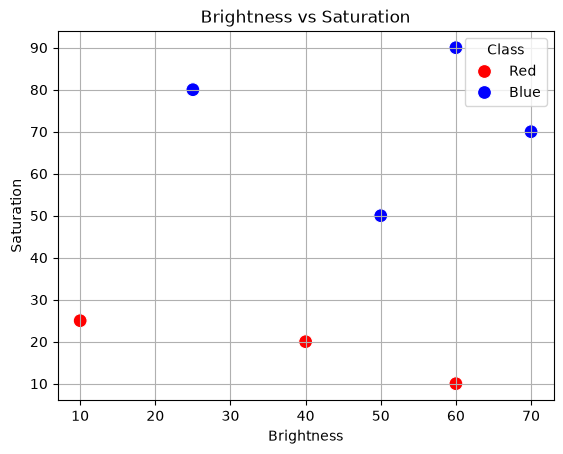

In [4]:
sns.scatterplot(x='Brightness', y='Saturation', hue='Class', data=df, palette={'Red': 'red', 'Blue': 'blue'}, s=100)
plt.title('Brightness vs Saturation')
plt.grid(True)
plt.show()

In [5]:
new_entry = np.array([40, 40])

def euclidean_distance(row):
    point = np.array([row['Brightness'], row['Saturation']])
    return np.sqrt(np.sum((point - new_entry) ** 2))

df['Distance'] = df.apply(euclidean_distance, axis=1)
df.sort_values(by='Distance')

,Brightness,Saturation,Class,Distance
1,50,50,Blue,14.142136
0,40,20,Red,20.000000
3,10,25,Red,33.541020
5,60,10,Red,36.055513
4,70,70,Blue,42.426407
6,25,80,Blue,42.720019
2,60,90,Blue,53.851648


In [6]:
# Separate features and labels
X = df[['Brightness', 'Saturation']]
y = df['Class']

# Initialize and fit KNN model with k=3
knn = KNeighborsClassifier(n_neighbors=3, metric='euclidean')
knn.fit(X, y)

# Predict the class for the new entry
import warnings
warnings.filterwarnings('ignore', category=UserWarning)
predicted_class = knn.predict([new_entry])[0]
print(f"The predicted class for the new entry {new_entry} with k=3 is: {predicted_class}")

The predicted class for the new entry [40 40] with k=3 is: Red


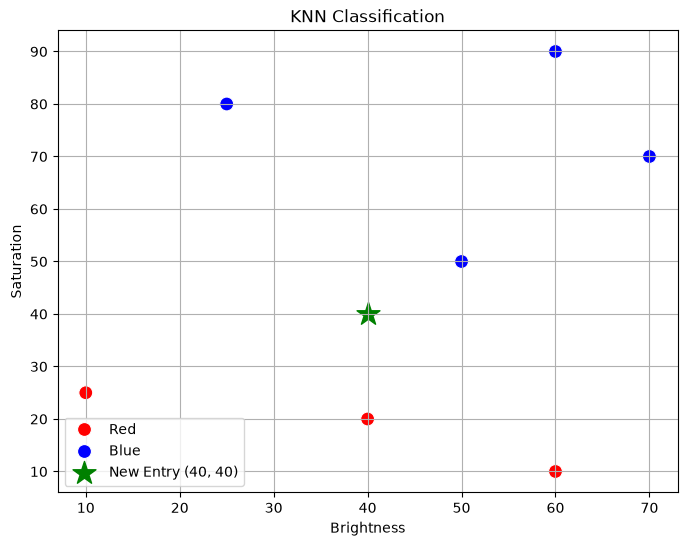

In [7]:
plt.figure(figsize=(8, 6))
sns.scatterplot(x='Brightness', y='Saturation', hue='Class', data=df, palette={'Red': 'red', 'Blue': 'blue'}, s=100)
plt.scatter(new_entry[0], new_entry[1], color='green', marker='*', s=300, label='New Entry (40, 40)')
plt.title('KNN Classification')
plt.legend()
plt.grid(True)
plt.show()